In [1]:
words = open("isimler.txt", "r").read().splitlines()

In [2]:
words[:10]

['aba',
 'abadan',
 'abak',
 'abaka',
 'abakan',
 'abakay',
 'abar',
 'abasıyanık',
 'abaş',
 'abaşkatun']

## Bigram Countlama

In [3]:
b = {}
for word in words:
    chs = ['<S>'] + list(word) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1
        

In [4]:
b

{('<S>', 'a'): 442,
 ('a', 'b'): 101,
 ('b', 'a'): 277,
 ('a', '<E>'): 294,
 ('a', 'd'): 73,
 ('d', 'a'): 81,
 ('a', 'n'): 468,
 ('n', '<E>'): 653,
 ('a', 'k'): 254,
 ('k', '<E>'): 406,
 ('k', 'a'): 399,
 ('a', 'y'): 332,
 ('y', '<E>'): 111,
 ('a', 'r'): 393,
 ('r', '<E>'): 275,
 ('a', 's'): 63,
 ('s', 'ı'): 50,
 ('ı', 'y'): 14,
 ('y', 'a'): 188,
 ('n', 'ı'): 16,
 ('ı', 'k'): 78,
 ('a', 'ş'): 66,
 ('ş', '<E>'): 159,
 ('ş', 'k'): 12,
 ('a', 't'): 154,
 ('t', 'u'): 215,
 ('u', 'n'): 197,
 ('a', 'z'): 53,
 ('z', 'a'): 26,
 ('b', 'b'): 1,
 ('s', '<E>'): 28,
 ('b', 'd'): 9,
 ('a', 'l'): 249,
 ('l', '<E>'): 123,
 ('d', 'i'): 51,
 ('i', '<E>'): 92,
 ('d', 'u'): 74,
 ('u', 'l'): 165,
 ('l', 'l'): 6,
 ('l', 'a'): 174,
 ('a', 'h'): 29,
 ('h', '<E>'): 6,
 ('d', 'ü'): 19,
 ('ü', 'l'): 85,
 ('l', 'h'): 2,
 ('h', 'a'): 43,
 ('h', 'e'): 3,
 ('e', 'y'): 57,
 ('ü', 's'): 14,
 ('s', 's'): 3,
 ('s', 'a'): 113,
 ('a', 'm'): 79,
 ('m', 'e'): 78,
 ('e', 'd'): 16,
 ('d', '<E>'): 8,
 ('e', 't'): 59,
 ('t', '<

In [10]:
n = len(stoi)
n

30

## Tensor Countlama

In [11]:
import torch

N = torch.zeros((30, 30), dtype=torch.int32)
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

b = {}
for word in words:
    chs = ['.'] + list(word) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1
        

In [12]:
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'r': 17,
 's': 18,
 't': 19,
 'u': 20,
 'v': 21,
 'y': 22,
 'z': 23,
 'ç': 24,
 'ö': 25,
 'ü': 26,
 'ğ': 27,
 'ı': 28,
 'ş': 29,
 '.': 0}

In [13]:
# stoi reversed. Instead of index -> string, now here string -> index
itos = {s:i for i,s in stoi.items()}

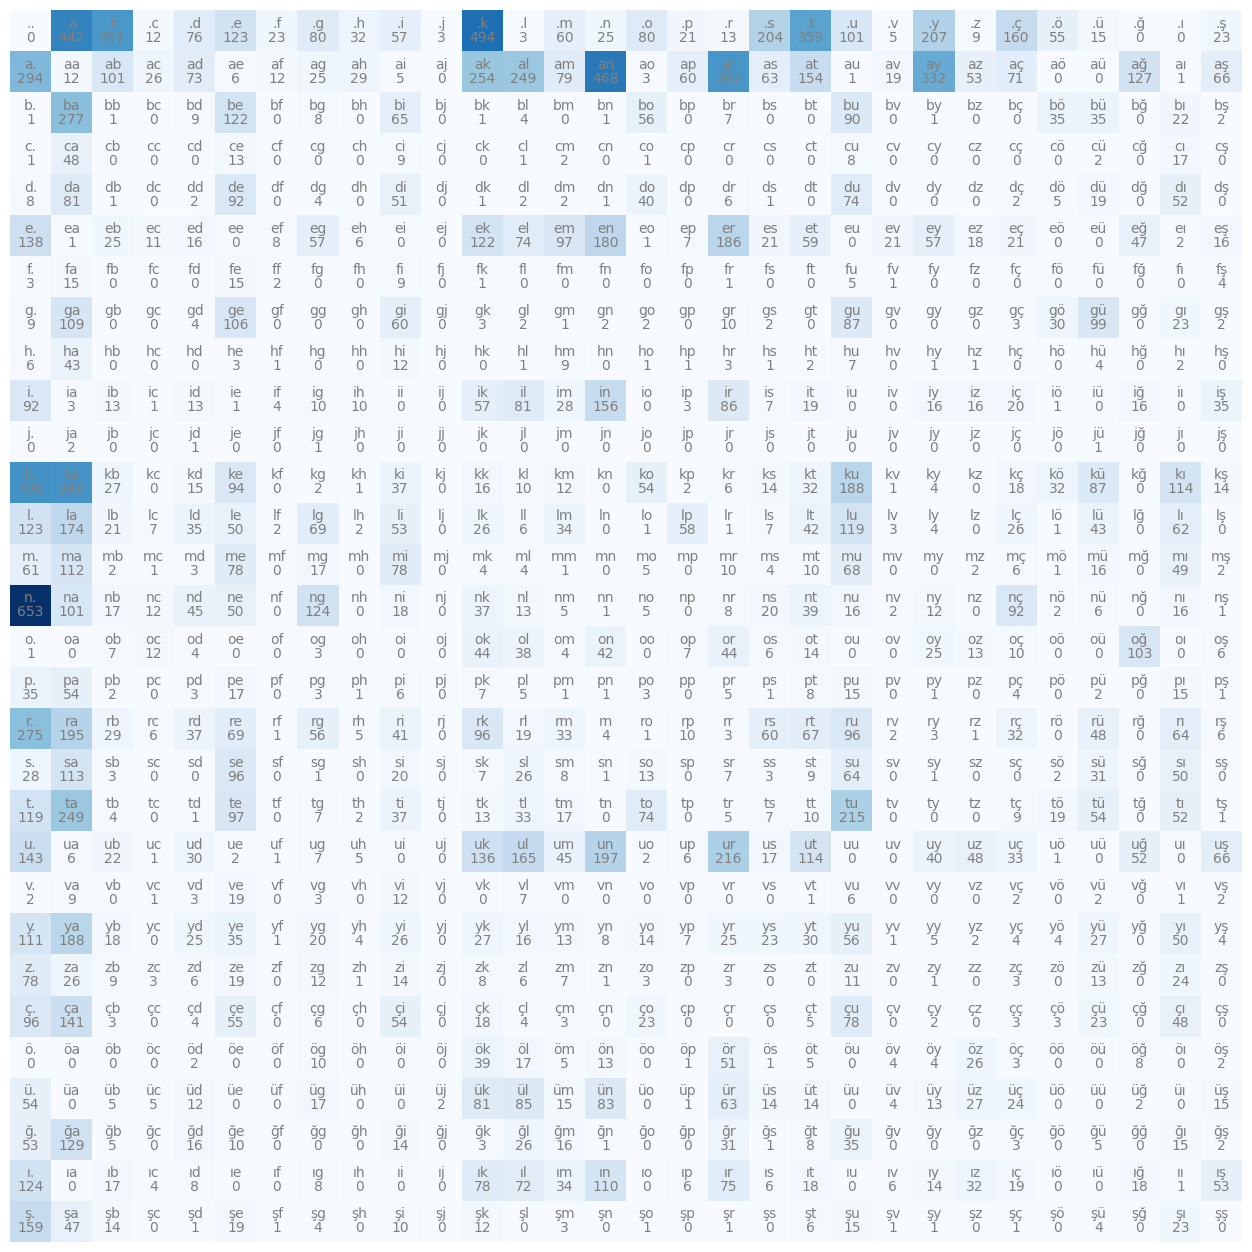

In [15]:
import matplotlib.pyplot as plt
%matplotlib inline

size = 30
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(size):
    for j in range(size):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [16]:
P = (N+1).float()
P /= P.sum(1, keepdim=True)


In [17]:
g = torch.Generator().manual_seed(2147483647)
for i in range(5):
    ix = 0
    out = []
    while True:
        p = P[ix]
        #p = N[ix].float()
        #p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print("".join(out))

unsrançmokslbör.
e.
çerdış.
tmur.
baçulgüze.


In [18]:
log_likelihood = 0.0
n = 0

for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        print(f'{ch1}{ch2}: {prob :.4f} {logprob :.4f}')
print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

.a: 0.1428 -1.9466
ab: 0.0339 -3.3834
ba: 0.3625 -1.0149
a.: 0.0981 -2.3214
.a: 0.1428 -1.9466
ab: 0.0339 -3.3834
ba: 0.3625 -1.0149
ad: 0.0246 -3.7043
da: 0.1730 -1.7545
an: 0.1560 -1.8578
n.: 0.4936 -0.7061
.a: 0.1428 -1.9466
ab: 0.0339 -3.3834
ba: 0.3625 -1.0149
ak: 0.0848 -2.4671
k.: 0.2520 -1.3783
log_likelihood=tensor(-33.2238)
nll=tensor(33.2238)
2.076488733291626


In [19]:
xs, ys = [], []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((30, 30), generator=g, requires_grad=True)

number of examples:  22759


In [31]:
import torch.nn.functional as F
# gradient descent
for k in range(1000):
    # forward pass
    xenc = F.one_hot(xs, num_classes=30).float()
    logits = xenc @ W 
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims=True)
    loss = -probs[torch.arange(num), ys]. log().mean()
    print(loss.item())

    # backward pass
    W.grad = None 
    loss.backward()

    # update
    W.data += -100 * W.grad

2.751997947692871
2.572920083999634
2.4884889125823975
2.450226306915283
2.4405100345611572
2.440345287322998
2.439746618270874
2.4400084018707275
2.4396204948425293
2.4399805068969727
2.439629554748535
2.440051555633545
2.4396860599517822
2.4401586055755615
2.439756393432617
2.4402711391448975
2.4398250579833984
2.4403741359710693
2.439884662628174
2.440460681915283
2.439932346343994
2.4405295848846436
2.4399688243865967
2.4405810832977295
2.439995527267456
2.4406192302703857
2.440014362335205
2.4406464099884033
2.4400277137756348
2.4406657218933105
2.4400362968444824
2.440678596496582
2.4400417804718018
2.440687894821167
2.4400453567504883
2.4406936168670654
2.440047264099121
2.44069766998291
2.4400484561920166
2.4407002925872803
2.4400486946105957
2.440701723098755
2.4400486946105957
2.440702438354492
2.4400486946105957
2.4407031536102295
2.4400482177734375
2.4407033920288086
2.4400475025177
2.4407031536102295
2.440047025680542
2.4407026767730713
2.4400463104248047
2.440702438354492

In [32]:
nlls = torch.zeros(5)
for i in range(5):
    # i-th bigram:
    x = xs[i].item() # input character index
    y = ys[i].item() # label character index
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
    print('input to the neural net:', x)
    print('output probabilities from the neural net:', probs[i])
    print('label (actual next character):', y)
    p = probs[i, y]
    print('probability assigned by the net to the the correct character:', p.item())
    logp = torch.log(p)
    print('log likelihood:', logp.item())
    nll = -logp
    print('negative log likelihood:', nll.item())
    nlls[i] = nll

print('average negative log likelihood, i.e. loss =', nlls.mean().item())


bigram example 1: .a (indexes 0,1)
input to the neural net: 0
output probabilities from the neural net: tensor([2.4378e-05, 1.7930e-01, 1.3817e-01, 3.9518e-03, 2.5095e-02, 4.0700e-02,
        7.5791e-03, 2.6420e-02, 1.0549e-02, 1.8808e-02, 9.8561e-04, 9.9655e-02,
        9.8561e-04, 1.9800e-02, 8.2389e-03, 2.6420e-02, 6.9194e-03, 4.2814e-03,
        6.7865e-02, 1.2360e-01, 3.3385e-02, 1.6446e-03, 6.8882e-02, 2.9629e-03,
        5.3054e-02, 1.8146e-02, 4.9408e-03, 2.4229e-05, 2.4101e-05, 7.5791e-03],
       grad_fn=<SelectBackward0>)
label (actual next character): 1
probability assigned by the net to the the correct character: 0.17930203676223755
log likelihood: -1.7186834812164307
negative log likelihood: 1.7186834812164307
bigram example 2: ab (indexes 1,2)
input to the neural net: 1
output probabilities from the neural net: tensor([9.8788e-02, 4.0297e-03, 3.3936e-02, 8.7340e-03, 2.4527e-02, 2.0135e-03,
        4.0297e-03, 8.3979e-03, 9.7420e-03, 1.6775e-03, 2.3092e-05, 8.5347e-02,
  

In [33]:
g = torch.Generator().manual_seed(2147483647)
for i in range(5):
    ix = 0
    out = []
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=30).float()
        logits = xenc @ W
        counts = logits.exp()
        p = counts / counts.sum(1, keepdims=True)
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print("".join(out))

unsrançmokslbör.
e.
çerdış.
tmur.
kaçulgüze.
